<a href="https://colab.research.google.com/github/mmuwale/Data-Wrangling/blob/main/Airplane_Crashing_Data_Cleaning_ipnyb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("saurograndi/airplane-crashes-since-1908")

print("Path to dataset files:", path)

100%|██████████| 564k/564k [00:00<00:00, 929kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/saurograndi/airplane-crashes-since-1908/versions/4


In [ ]:
import pandas as pd

df = pd.read_csv(path + "/Airplane_Crashes_and_Fatalities_Since_1908.csv")
rows = df.shape[0]
columns = df.shape[1]

print(f"Number of rows: {rows}")
print(f"Number of columns: {columns}")


Number of rows: 5268
Number of columns: 13


In [ ]:
# Task 3: Display the last 75 rows
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


## Treatment of Missing Data

The appropriate method for treating missing data depends on the type
of variable and the meaning of the missing values.

| Column | Missing Data Treatment | Justification |
|---|---|---|
| Date | Leave missing / investigate and reconstruct where possible | Date is a temporal variable, so using the mean or mode would not be appropriate. |
| Time | Leave missing or use the mode | Time is a categorical/time variable. A mean would not be meaningful. |
| Location | Replace with "Unknown" | Location is categorical, and assigning the most common location could introduce incorrect information. |
| Operator | Replace with "Unknown" | Operator is categorical. Using the mode could incorrectly assign an operator to a crash. |
| Flight # | Leave missing / replace with "Unknown" | Flight number is an identifier, so statistical imputation such as mean or median is inappropriate. |
| Route | Replace with "Unknown" | Route is categorical and cannot meaningfully be calculated or averaged. |
| Type | Replace with "Unknown" or use the mode | Aircraft type is categorical. "Unknown" avoids assuming that the missing aircraft had the most common type. |
| Registration | Replace with "Unknown"| Aircraft registration is unique. It is either known or unknown|
| cn/In | Replace with "Unknown"| Aircraft cn/In is unique. It cannot be estimated|
| Aboard | Median imputation | Aboard is numerical, and the median is less affected by extreme values than the mean. |
| Fatalities | Median imputation | Fatalities is numerical and can contain extreme values, so the median is more robust than the mean. |
| Ground | Replace with 0 if missing means no ground fatalities; otherwise median | Ground fatalities are numerical. If the dataset defines missing values as no ground fatalities, zero is the most appropriate replacement. |
| Summary | Replace with "Unknown" | Summary is text, so numerical imputation is inappropriate. |

In [ ]:
# Task 5: Create the fatality_locations dataframe
fatality_locations = df[['Date', 'Location', 'Aboard', 'Fatalities']].copy()
fatality_locations.head()

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0


In [ ]:
# Task 6: Determine the date with the highest recorded fatalities
max_fatality_row = fatality_locations.loc[fatality_locations['Fatalities'].idxmax()]
print('Date with the highest recorded fatalities:', max_fatality_row['Date'])
print('Fatalities:', int(max_fatality_row['Fatalities']))

Date with the highest recorded fatalities: 03/27/1977
Fatalities: 583


In [ ]:
# Task 7: Compare passengers aboard with fatalities and count crashes with no fatalities
comparison = fatality_locations[['Aboard', 'Fatalities']].copy()
no_fatality_count = (fatality_locations['Fatalities'] == 0).sum()
print('Crashes with no fatalities:', int(no_fatality_count))
comparison.head(10)

Crashes with no fatalities: 58


,Aboard,Fatalities
0,2.0,1.0
1,5.0,5.0
2,1.0,1.0
3,20.0,14.0
4,30.0,30.0
5,41.0,21.0
6,19.0,19.0
7,20.0,20.0
8,22.0,22.0
9,19.0,19.0


In [ ]:
# Task 8: Split Location into Region and State/Country
location_parts = fatality_locations['Location'].fillna('Unknown').str.split(',', n=1, expand=True)
fatality_locations['Region'] = location_parts[0].str.strip()
fatality_locations['State/Country'] = location_parts[1].fillna('Unknown').str.strip()
fatality_locations[['Location', 'Region', 'State/Country']].head()

,Location,Region,State/Country
0,"Fort Myer, Virginia",Fort Myer,Virginia
1,"AtlantiCity, New Jersey",AtlantiCity,New Jersey
2,"Victoria, British Columbia, Canada",Victoria,"British Columbia, Canada"
3,Over the North Sea,Over the North Sea,Unknown
4,"Near Johannisthal, Germany",Near Johannisthal,Germany


In [ ]:
# Task 9: Order by fatalities from highest to lowest and select the first 100
top_100_fatalities = fatality_locations.sort_values('Fatalities', ascending=False).head(100).reset_index(drop=True)
top_100_fatalities.head()

,Date,Location,Aboard,Fatalities,Region,State/Country
0,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,Tenerife,Canary Islands
1,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,Mt. Osutaka,"near Ueno Village, Japan"
2,11/12/1996,"Near Charkhidadri, India",349.0,349.0,Near Charkhidadri,India
3,03/03/1974,"Near Ermenonville, France",346.0,346.0,Near Ermenonville,France
4,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,AtlantiOcean,110 miles West of Ireland


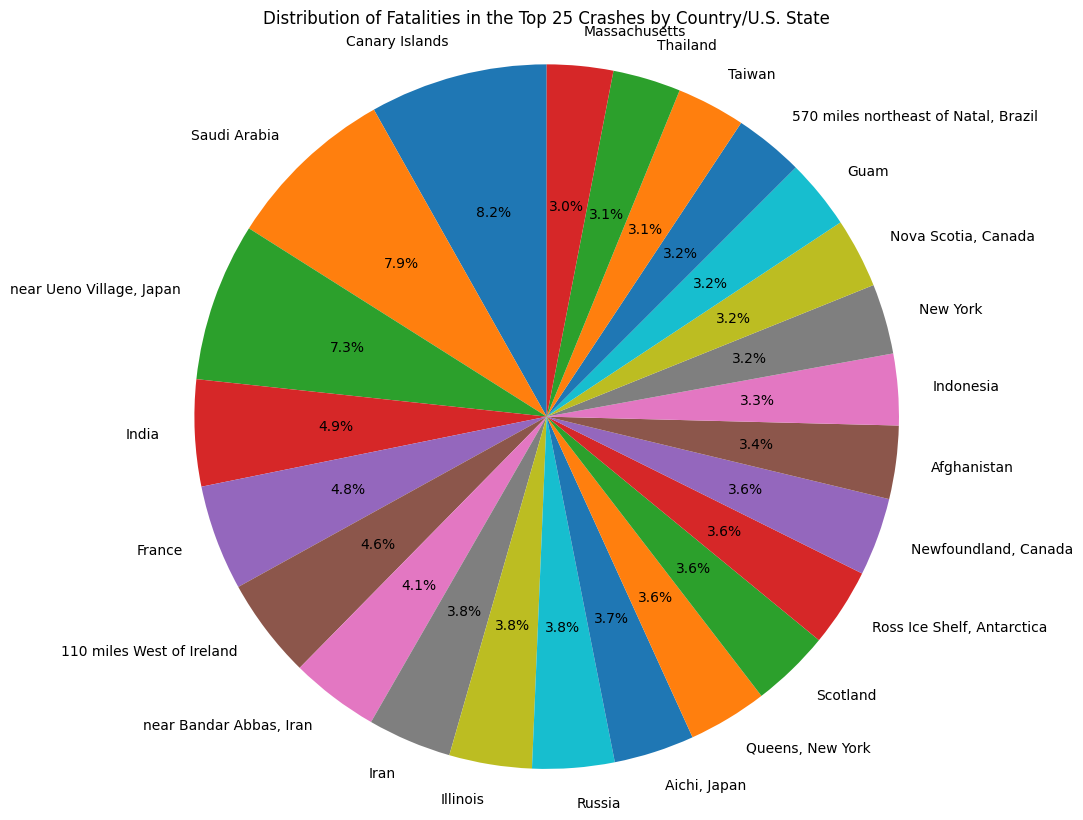

In [ ]:
# Task 10: Pie chart of fatalities in the top 25 crashes by country/U.S. State; import seaborn as sns; import matplotlib.pyplot as plt; top_25_fatalities = fatality_locations.sort_values('Fatalities', ascending=False).head(25); fatalities_by_country = top_25_fatalities.groupby('State/Country')['Fatalities'].sum().sort_values(ascending=False); plt.figure(figsize=(10, 10)); plt.pie(fatalities_by_country.values, labels=fatalities_by_country.index, autopct='%1.1f%%', startangle=90); plt.title('Distribution of Fatalities in the Top 25 Crashes by Country/U.S. State'); plt.axis('equal'); plt.show()